<a href="https://colab.research.google.com/github/neurostatslab/error-in-variables-garon-2026/blob/main/demo_notebooks/001_eiv_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/neurostatslab/error-in-variables-garon-2026.git
import sys
sys.path.append('error-in-variables-garon-2026/')

!pip install -q "jax[cuda12]==0.6.0" "jaxlib==0.6.0" optax tensorflow-probability

import jax
from jax import config
config.update("jax_enable_x64", True)

import jax.numpy as jnp
import optax
from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions

import time

import utils
from core import EIV

Cloning into 'error-in-variables-garon-2026'...
remote: Enumerating objects: 303, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 303 (delta 64), reused 0 (delta 0), pack-reused 179 (from 1)
Receiving objects: 100% (303/303), 11.70 MiB | 23.21 MiB/s, done.
Resolving deltas: 100% (170/170), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 136.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 MB 21.6 MB/s eta 0:00:00


# Fit Model

### Construct Model Params

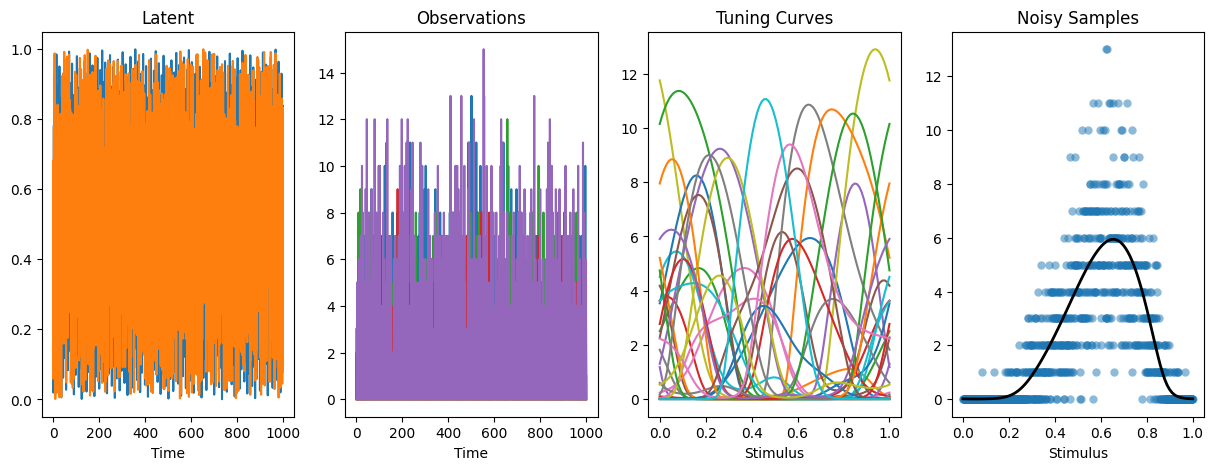

In [3]:
# Generative Hyperparams

num_neurons = 30
num_dims = 1
num_steps = 1000


# Construct Model
model = EIV(len_scale = .2,
            out_scale = 50.,
            kappa = 5.,
            num_dims=num_dims,
            num_neurons=num_neurons)

# Simulate Data
xs_true, y_and_s = model.simulate(
    num_steps=num_steps, key = jax.random.PRNGKey(7)
)

# Visualize Data
utils.plot_simulated_data_1D(xs_true, model.true_params, y_and_s, model);

### Fit Model

In [4]:

opt_params = {
    "opt_key":jax.random.PRNGKey(123),
    "init_key":jax.random.PRNGKey(456)
}

model.fit(y_and_s, "adam", opt_params)


100%|██████████| 1000/1000 [00:02<00:00, 388.43it/s]


### Plot Results

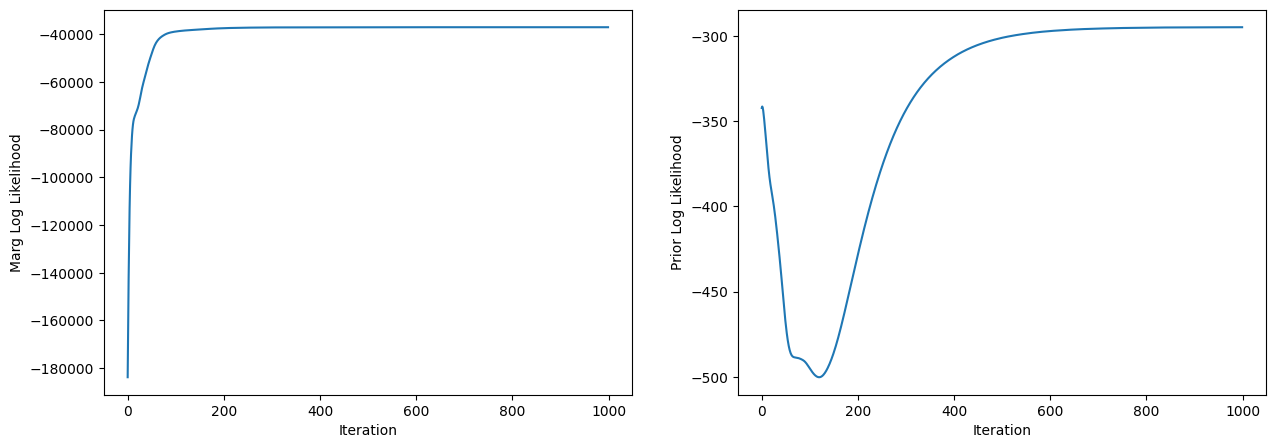

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


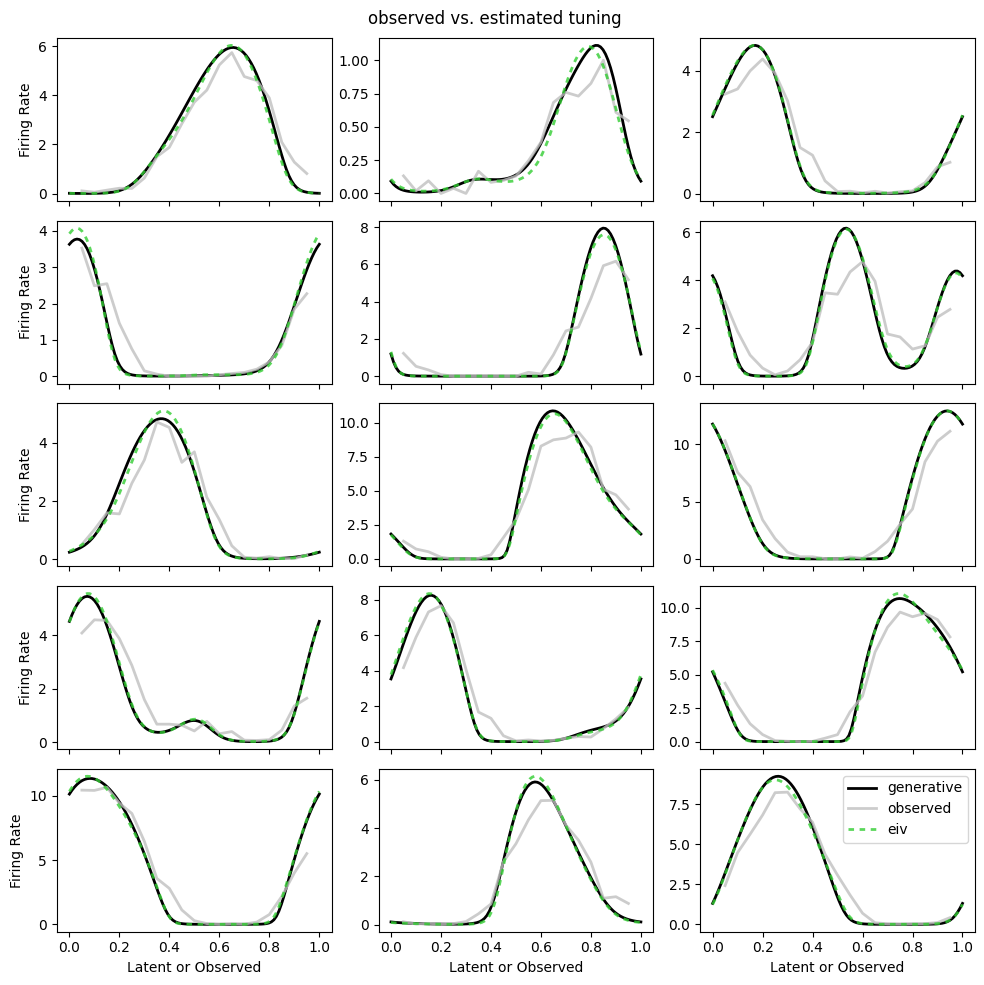

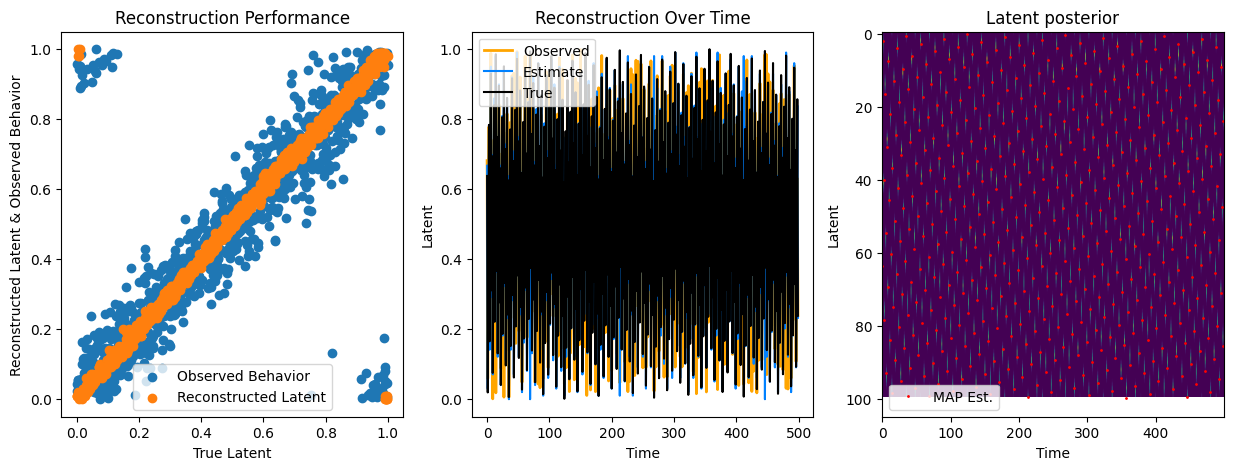

In [5]:
utils.plot_objhist(model);


x_grid = utils.make_xgrid(1, 100, 1.)
true_tunings = model.observation.mapping(model.true_params, x_grid)[0].T
utils.plot_real_tuning(model, true_tunings, y_and_s)

utils.plot_latent_recon_sim(model, y_and_s, xs_true)